In [2]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Configurazione PATH Miniconda
if not os.path.exists("/usr/local/miniconda"):
    print(" Configuration of the Conda environment for the first time...")
    !wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /tmp/miniconda.sh
    !bash /tmp/miniconda.sh -b -p /usr/local/miniconda
    os.environ["PATH"] = "/usr/local/miniconda/bin:" + os.environ["PATH"]

    !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
    !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
    
    !conda create -n openmmlab python=3.10 -y
    !conda run -n openmmlab pip install "numpy<2" torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cu118
    !conda run -n openmmlab pip install -U openmim
    !conda run -n openmmlab mim install mmengine "mmcv>=2.0.0rc4,<2.1.0" "mmdet>=3.0.0,<3.1.0"
    
    if not os.path.exists('/content/mmdetection3d'):
        !git clone https://github.com/open-mmlab/mmdetection3d.git -b dev-1.x /content/mmdetection3d
        %cd /content/mmdetection3d
        !conda run -n openmmlab pip install --no-build-isolation .
        %cd /content
    !conda run -n openmmlab pip install "numpy<2"
else:
    os.environ["PATH"] = "/usr/local/miniconda/bin:" + os.environ["PATH"]
    print(" Conda environment is already ready!")
    
    print(" Conda environment and OpenMMLab are active!")

Mounted at /content/drive
 Configuration of the Conda environment for the first time...
PREFIX=/usr/local/miniconda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local/miniconda
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.7.1


In [27]:
%cd /content
if not os.path.exists('/content/3D_Perception'):
    !git clone https://github.com/giacomosalvatori03/3D_Perception.git
%cd /content/3D_Perception
!git pull

/content
/content/3D_Perception
Already up to date.


In [6]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode none --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [BASELINE_100PERC] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/baseline_100perc

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/baseline_100perc/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/baseline_100perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [07:42<00:00,  1.08it/s]


In [7]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc"
)

results = evaluator.evaluate(exp_path)


 3D DETECTION mAP40 RESULTS [baseline_100perc]



,Easy,Moderate,Hard
Class,,,
Car,67.40%,62.71%,59.77%
Pedestrian,53.82%,49.63%,44.13%
Cyclist,48.11%,43.70%,42.59%



 Reports successfully saved in '/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc': .json, .csv, .md, .tex


In [9]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode random --subsample_ratio 0.75 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [RANDOM_75PERC] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/random_75perc

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/random_75perc/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/random_75perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:30<00:00, 16.15it/s]


In [10]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/random_75perc"
)

results = evaluator.evaluate(exp_path)


 3D DETECTION mAP40 RESULTS [random_75perc]



,Easy,Moderate,Hard
Class,,,
Car,67.31%,59.99%,57.16%
Pedestrian,54.86%,49.82%,45.12%
Cyclist,60.29%,45.11%,46.20%



 Reports successfully saved in '/content/drive/MyDrive/3D_Perception/experiments/random_75perc': .json, .csv, .md, .tex


In [11]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode random --subsample_ratio 0.50 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [RANDOM_50PERC] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/random_50perc

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/random_50perc/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/random_50perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:28<00:00, 17.32it/s]


In [12]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/random_50perc"
)

results = evaluator.evaluate(exp_path)


 3D DETECTION mAP40 RESULTS [random_50perc]



,Easy,Moderate,Hard
Class,,,
Car,64.33%,54.68%,51.54%
Pedestrian,49.56%,44.04%,40.65%
Cyclist,46.15%,28.98%,30.58%



 Reports successfully saved in '/content/drive/MyDrive/3D_Perception/experiments/random_50perc': .json, .csv, .md, .tex


In [13]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode random --subsample_ratio 0.25 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [RANDOM_25PERC] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/random_25perc

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/random_25perc/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/random_25perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:27<00:00, 18.17it/s]


In [14]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/random_25perc"
)

results = evaluator.evaluate(exp_path)


 3D DETECTION mAP40 RESULTS [random_25perc]



,Easy,Moderate,Hard
Class,,,
Car,56.60%,43.11%,37.47%
Pedestrian,43.57%,36.64%,34.20%
Cyclist,26.42%,17.24%,18.95%



 Reports successfully saved in '/content/drive/MyDrive/3D_Perception/experiments/random_25perc': .json, .csv, .md, .tex


 Saved compact grid visualization to Drive: /content/drive/MyDrive/3D_Perception/experiments/baseline_100perc/visualizations/summary_grid_bev.png


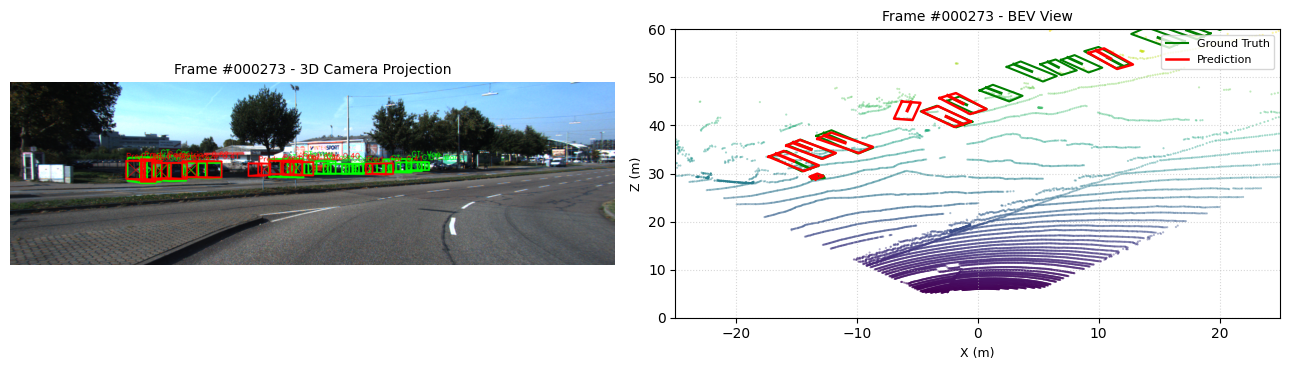

In [33]:
import importlib
import sys

import src

sys.path.insert(0, "/content/3D_Perception")

# Force module reload to clear Python cache
import scripts.sample_visualizer

importlib.reload(scripts.sample_visualizer)
from scripts.sample_visualizer import SampleVisualizer

# Initialize and render
visualizer = SampleVisualizer(
    data_path="/content/drive/MyDrive/3D_Perception/data/kitti_validation"
)

visualizer.visualize_experiment(
    exp_dir="/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc",
    num_samples=1,
    conf_thresh=0.3,
    grid_layout=True,
)

 Saved compact grid visualization to Drive: /content/drive/MyDrive/3D_Perception/experiments/random_50perc/visualizations/summary_grid_bev.png


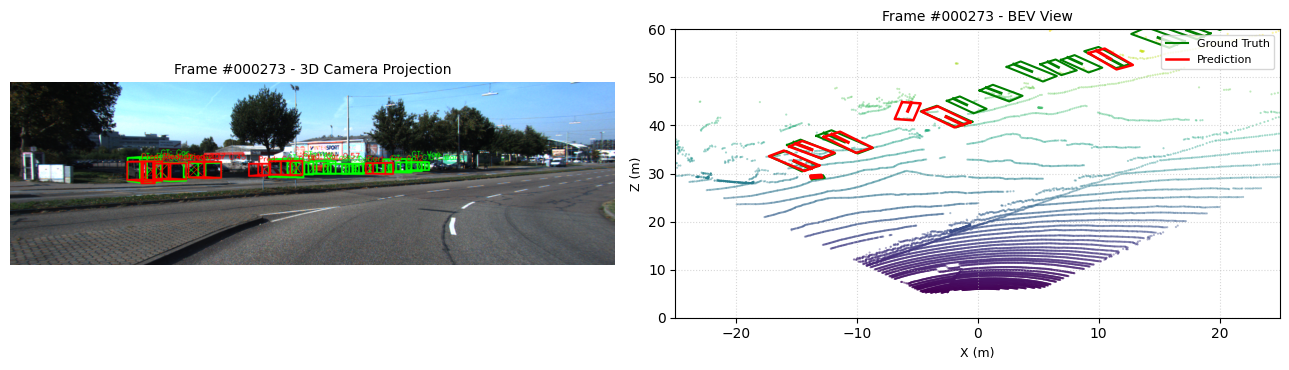

In [35]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.sample_visualizer import SampleVisualizer

# Inizializzazione
visualizer = SampleVisualizer(
    data_path="/content/drive/MyDrive/3D_Perception/data/kitti_validation"
)

# Visualizza i 3 frame più significativi
visualizer.visualize_experiment(
    exp_dir="/content/drive/MyDrive/3D_Perception/experiments/random_50perc",
    num_samples=1,
    conf_thresh=0.3,
)

 Saved compact grid visualization to Drive: /content/drive/MyDrive/3D_Perception/experiments/random_25perc/visualizations/summary_grid_bev.png


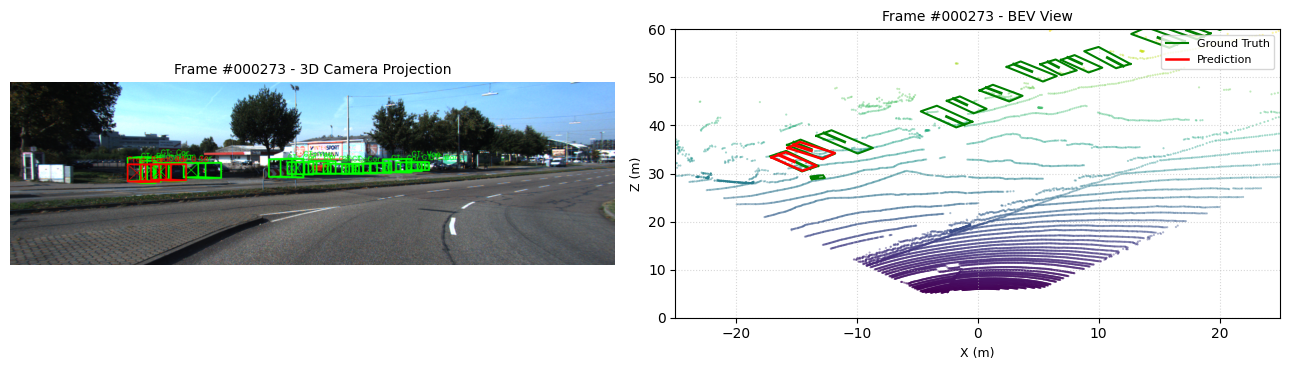

In [36]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.sample_visualizer import SampleVisualizer

# Inizializzazione
visualizer = SampleVisualizer(
    data_path="/content/drive/MyDrive/3D_Perception/data/kitti_validation"
)

# Visualizza i 3 frame più significativi
visualizer.visualize_experiment(
    exp_dir="/content/drive/MyDrive/3D_Perception/experiments/random_25perc",
    num_samples=1,
    conf_thresh=0.3,
)

In [38]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode beam --num_beams 64 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [BEAM_64RINGS] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/beam_64rings

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/beam_64rings/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/beam_64rings/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:30<00:00, 16.28it/s]


In [39]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/beam_64rings"
)

results = evaluator.evaluate(exp_path)


 3D DETECTION mAP40 RESULTS [beam_64rings]



,Easy,Moderate,Hard
Class,,,
Car,67.40%,62.71%,59.77%
Pedestrian,53.82%,49.63%,44.13%
Cyclist,48.11%,43.70%,42.59%



 Reports successfully saved in '/content/drive/MyDrive/3D_Perception/experiments/beam_64rings': .json, .csv, .md, .tex
